In [1]:
import math
import numpy as np
import scipy.stats as scs
import statsmodels.api as sm
from pylab import mpl, plt

In [3]:
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

### 기하 브라운 운동(Geometric Brownian Motion, GBM)

미래의 주가가 어떻게 변할지 수천 개의 가상 시나리오(경로)를 그려보는 **몬테카를로 시뮬레이션(Monte Carlo Simulation)**의 핵심 로직

**수학적 배경 (기하 브라운 운동)**

이 코드는 다음의 확률미분방정식(SDE)을 이산화(Discretization)한 결과입니다.

$$S_t = S_{t-\Delta t} \exp\left(\left(r - \frac{1}{2}\sigma^2\right)\Delta t + \sigma \sqrt{\Delta t} z_t\right)$$

$r - \frac{1}{2}\sigma^2$: 주가의 평균적인 상승 흐름(Drift)에서 변동성을 보정한 값입니다.

$\sigma \sqrt{\Delta t} z_t$: 무작위로 발생하는 충격(Volatility)입니다. $z_t$는 표준정규분포를 따르는 난수입니다.

In [10]:
# 기하 브라운 운동의 몬테카를로 표본을 생상하는 함수
def gen_paths(S0, r, sigma, T, M, I):
    """기하 브라운 운동에 대한 몬테카를로 경로를 생성
    인수
    ========================
    S0: float
        초기 주가/지수 수준
    r: float
        고정 단기 이자율
    sigma: float
        고정 변동성
    T: float
        최종 시간
    M: int
        시간 구간의 개수
    I: int
        시뮬레이션 경로의 개수
    ========================
    
    paths: ndarray, shape(M + 1, I)
    """
    dt = T / M
    paths = np.zeros((M + 1 , I))
    paths[0] = S0
    for t in range(1, M + 1):
        rand = np.random.standard_normal(I)
        rand = (rand - rand.mean()) / rand.std() # 1차 및 2차 모멘트 매칭
        paths[t] = paths[t -1] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * math.sqrt(dt) * rand) # 기하 브라운 운동에 대한 벡터화된 오일러 이산화
    return paths

금융공학 시뮬레이션에서 **모멘트 매칭(Moment Matching)**과 **오일러 이산화(Euler Discretization)**는 이론과 실제 계산 사이의 간극을 메워주는 아주 중요한 기술들입니다.

1. **모멘트 매칭 (Moment Matching)**
통계학에서 '모멘트(Moment)'는 평균(1차), 분산(2차) 같은 분포의 특성값을 말합니다.모멘트 매칭은 무작위로 생성한 난수들이 <u>우리가 원하는 통계적 특성(평균 0, 표준편차 1)을 완벽하게 따르도록 강제로 교정</u>하는 기법입니다. 
- **왜 하나요?** 컴퓨터가 생성하는 난수는 표본의 크기가 작을수록 평균이 0.001이거나 표준편차가 0.99인 식으로 오차가 발생합니다. 이 미세한 오차가 시뮬레이션을 수천 번 반복하면 결과값(주가)을 왜곡시킬 수 있습니다.
- **어떻게 하나요?**
    1.  난수 집합 $z$를 생성합니다.
    2.  $z$에서 평균을 빼고 표준편차로 나눕니다: $z_{new} = \frac{z - \text{mean}(z)}{\text{std}(z)}$
- **결과:** 이렇게 하면 어떤 난수 집합이든 평균은 정확히 0, 표준편차는 정확히 1이 됩니다. 시뮬레이션의 수렴 속도를 높여주는 일종의 '치트키' 같은 기술입니다.

2. **오일러 이산화 (Euler Discretization)**
금융공학의 주가 모델은 보통 시간($t$)이 흐르는 연속적인 확률미분방정식(SDE)으로 표현됩니다. 하지만 컴퓨터는 연속적인 시간을 이해할 수 없으므로, 시간을 아주 작은 단위($\Delta t$)로 쪼개서 계산해야 합니다. <u>이렇게 **연속적인 수식을 디지털(계단식)로 바꾸는 과정**을 **이산화**라고 합니다.</u>그중 오일러 방법은 가장 기본적이고 직관적인 방식입니다.  
- **핵심 원리**: "현재 값에 (변화율 $\times$ 시간 간격)을 더하면 다음 값이 된다"는 논리입니다.  
- **GBM에서의 적용**: 주가($S$)의 변화는 로그 수익률 공간에서 직선적인 흐름(Drift)과 무작위 충격(Diffusion)의 합으로 계산됩니다.
$$S_{t+\Delta t} = S_t + (\text{상승분} \times \Delta t) + (\text{변동성} \times \sqrt{\Delta t} \times \text{난수})$$

In [15]:
S0 = 100. # 시뮬레이션 과정의 초깃값
r = 0.05 # 고정 단기 이자율
sigma = 0.2 # 고정 변동성
T = 1.0 # 연 단위 시간
M = 50 # 시간 구간의 수
I = 250000 # 시뮬레이션 경로의 수
np.random.seed(1000)

In [16]:
paths = gen_paths(S0, r, sigma, T, M, I)

In [ ]:
S0 * math.exp(r * T) # 이론적 배경: 무위험 이자율 r만큼 주가가 우상향한다는 가정하의 기댓값입니다.

105.12710963760242

In [20]:
paths[-1].mean() # 시뮬레이션의 평균

105.12645392478755

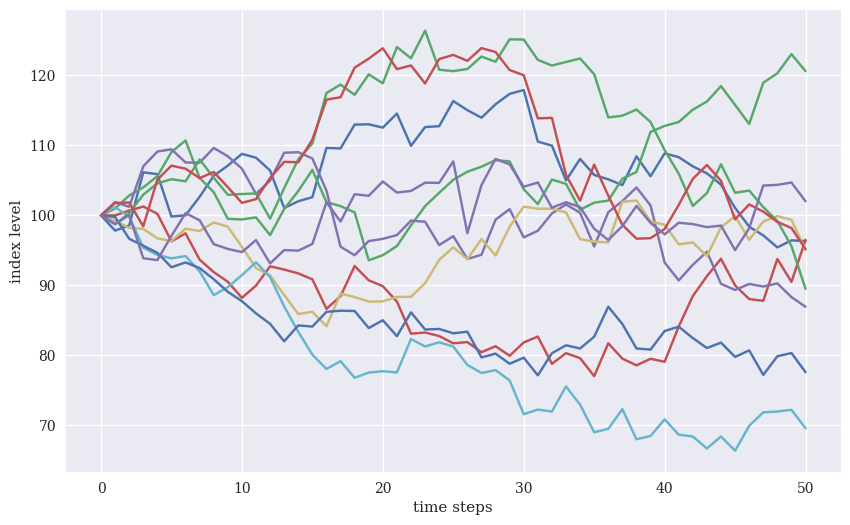

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(paths[:, :10])
plt.xlabel('time steps')
plt.ylabel('index level');

**시뮬레이션 이미지 분석: "미래 주가의 지도"**
첨부하신 그래프는 앞서 코드로 구현했던 기하 브라운 운동(GBM) 모델의 실행 결과입니다.
- 시작점(100): 모든 경로는 현재 주가인 100에서 시작합니다. **다양한 경로(Paths)**: 동일한 조건(이자율 $r$, 변동성 $\sigma$) 하에서도 무작위 충격(Random walk)에 의해 주가가 어떻게 달라질 수 있는지 보여주는 수십 개의 시나리오입니다.
- 변동성의 시각화: 시간이 흐를수록(Time steps 0 → 50) 주가의 범위가 위아래로 넓게 퍼지는 것을 볼 수 있습니다. 이것이 바로 주식 투자의 불확실성을 통계적으로 보여주는 모습입니다.
- 추세 확인: 전체적인 경로들의 중심축이 살짝 우상향하거나 평행하다면, 그것이 아까 언급하신 이론적 기댓값($S_0 e^{rT}$)의 방향입니다.

In [23]:
paths[:, 0].round(4)

array([100.    ,  97.821 ,  98.5573, 106.1546, 105.899 ,  99.8363,
       100.0145, 102.6589, 105.6643, 107.1107, 108.7943, 108.2449,
       106.4105, 101.0575, 102.0197, 102.6052, 109.6419, 109.5725,
       112.9766, 113.0225, 112.5476, 114.5585, 109.942 , 112.6271,
       112.7502, 116.3453, 115.0443, 113.9586, 115.8831, 117.3705,
       117.9185, 110.5539, 109.9687, 104.9957, 108.0679, 105.7822,
       105.1585, 104.3304, 108.4387, 105.5963, 108.866 , 108.3284,
       107.0077, 106.0034, 104.3964, 101.0637,  98.3776,  97.135 ,
        95.4254,  96.4271,  96.3386])

In [24]:
log_returns = np.log(paths[1:] / paths[:-1])

In [25]:
log_returns[:, 0].round(4)

array([-0.022 ,  0.0075,  0.0743, -0.0024, -0.059 ,  0.0018,  0.0261,
        0.0289,  0.0136,  0.0156, -0.0051, -0.0171, -0.0516,  0.0095,
        0.0057,  0.0663, -0.0006,  0.0306,  0.0004, -0.0042,  0.0177,
       -0.0411,  0.0241,  0.0011,  0.0314, -0.0112, -0.0095,  0.0167,
        0.0128,  0.0047, -0.0645, -0.0053, -0.0463,  0.0288, -0.0214,
       -0.0059, -0.0079,  0.0386, -0.0266,  0.0305, -0.0049, -0.0123,
       -0.0094, -0.0153, -0.0324, -0.0269, -0.0127, -0.0178,  0.0104,
       -0.0009])

In [28]:
def print_statistics(array):
    """선택한 통계를 출력
    인수
    =====================
    array: ndarray
        통계를 생성할 대상 객체
    """
    sta = scs.describe(array)
    print ('%14s %15.5s' % ('statistic', 'value'))
    print(30 * '-')
    print ('%14s %15.5f' % ('size', sta[0]))
    print ('%14s %15.5f' % ('min', sta[1][0]))
    print ('%14s %15.5f' % ('max', sta[1][1]))
    print ('%14s %15.5f' % ('mean', sta[2]))
    print ('%14s %15.5f' % ('std', np.sqrt(sta[3])))
    print ('%14s %15.5f' % ('skew', sta[4]))
    print ('%14s %15.5f' % ('kurtosis', sta[5]))  

In [29]:
print_statistics(log_returns.flatten())

     statistic           value
------------------------------
          size  12500000.00000
           min        -0.15664
           max         0.15371
          mean         0.00060
           std         0.02828
          skew         0.00055
      kurtosis         0.00085


In [30]:
log_returns.mean() * M + 0.5 * sigma ** 2 # 이토항 수정 후의 연율화된 평균 로그 수익률

0.05000000000000006

In [31]:
log_returns.std() * math.sqrt(M) # 연율화된 변동성. 로그 수익률의 연율화된 표준편차

0.20000000000000015

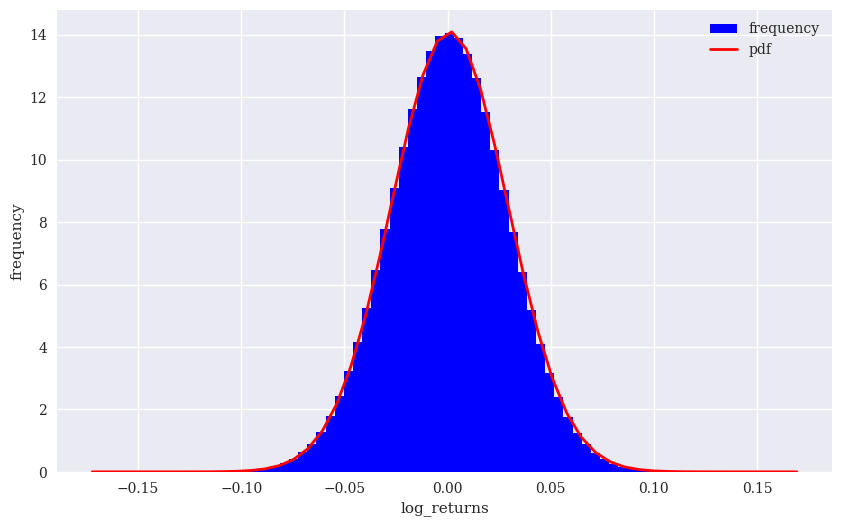

In [32]:
plt.figure(figsize=(10, 6))
plt.hist(log_returns.flatten(), bins=70, density=True,
         label='frequency', color='b')
plt.xlabel('log_returns')
plt.ylabel('frequency')
x = np.linspace(plt.axis()[0], plt.axis()[1])
plt.plot(x, scs.norm.pdf(x, loc=r / M, scale=sigma /np.sqrt(M)),
         'r', lw=2.0, label='pdf')
plt.legend();

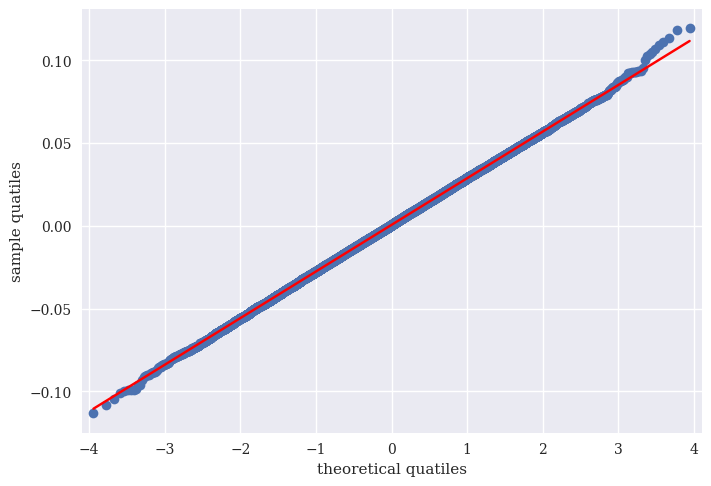

In [44]:
sm.qqplot(log_returns.flatten()[::500], line='s')
plt.xlabel('theoretical quatiles')
plt.ylabel('sample quatiles');

In [34]:
def normality_tests(arr):
    """주어진 데이터 분포의 정규성 검정
    
    인수
    ===========================
    array: ndarray
        통계를 생성할 대상 객체
    """
    print('Skew of data set %14.3f' % scs.skew(arr))
    print('Skew test p-value % 14.3f' % scs.skewtest(arr)[1])
    print('Kurt of data set %14.3f' % scs.kurtosis(arr))
    print('Kurt test p-value %14.3f' % scs.kurtosistest(arr)[1])
    print('Norm test p-value %14.3f' % scs.normaltest(arr)[1])

In [35]:
normality_tests(log_returns.flatten())

Skew of data set          0.001
Skew test p-value          0.430
Kurt of data set          0.001
Kurt test p-value          0.541
Norm test p-value          0.607


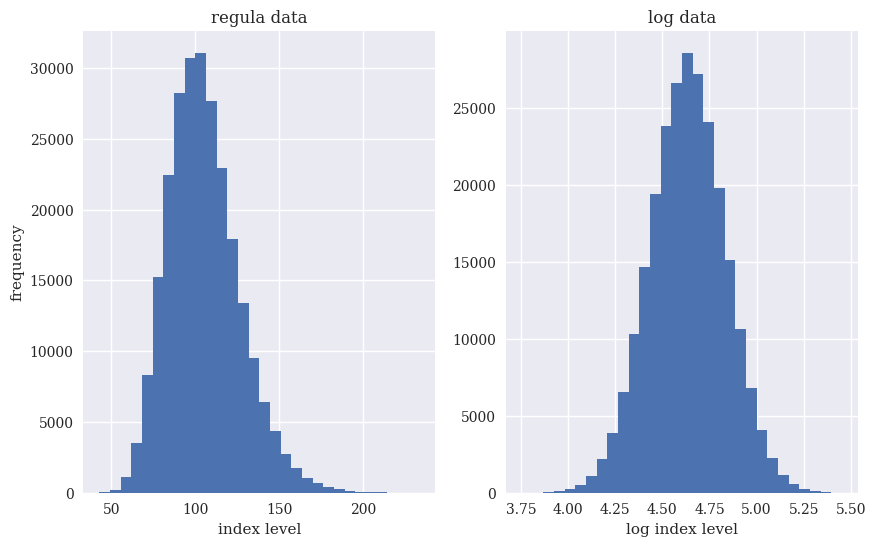

In [45]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
ax1.hist(paths[-1], bins=30)
ax1.set_xlabel('index level')
ax1.set_ylabel('frequency')
ax1.set_title('regula data')
ax2.hist(np.log(paths[-1]), bins=30)
ax2.set_xlabel('log index level')
ax2.set_title('log data');

In [38]:
print_statistics(paths[-1])

     statistic           value
------------------------------
          size    250000.00000
           min        42.74870
           max       233.58435
          mean       105.12645
           std        21.23174
          skew         0.61116
      kurtosis         0.65182


In [39]:
print_statistics(np.log(paths[-1]))

     statistic           value
------------------------------
          size    250000.00000
           min         3.75534
           max         5.45354
          mean         4.63517
           std         0.19998
          skew        -0.00092
      kurtosis        -0.00327


In [40]:
normality_tests(np.log(paths[-1]))

Skew of data set         -0.001
Skew test p-value          0.851
Kurt of data set         -0.003
Kurt test p-value          0.744
Norm test p-value          0.931


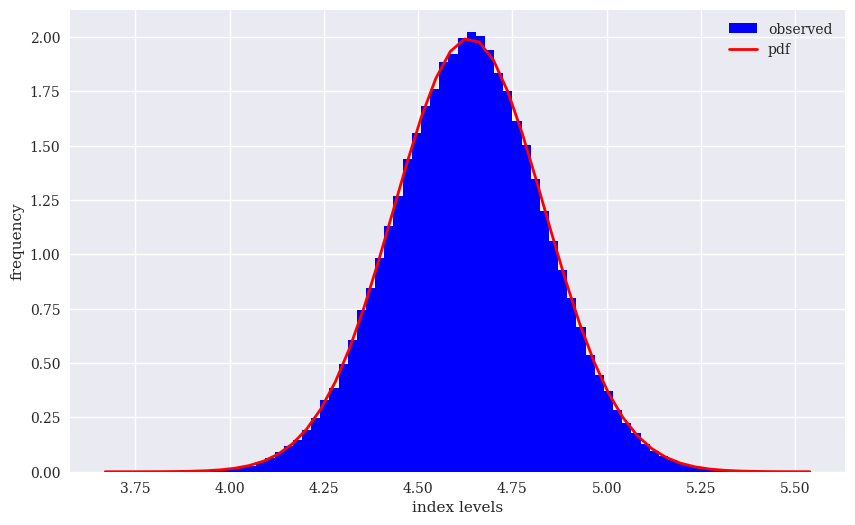

In [42]:
plt.figure(figsize=(10, 6))
log_data = np.log(paths[-1])
plt.hist(log_data, bins=70, density=True,
         label='observed', color='b')
plt.xlabel('index levels')
plt.ylabel('frequency')
x = np.linspace(plt.axis()[0], plt.axis()[1])
plt.plot(x, scs.norm.pdf(x, log_data.mean(), log_data.std()),
         'r', lw=2.0, label='pdf')
plt.legend();